In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
conn = sqlite3.connect("egac.db")

query = """
SELECT 
    i.id AS institution_id,
    i.name AS institution_name,
    i.class_name AS class,
    l.city AS city,
    l.region AS region,
    COUNT(DISTINCT c.id) AS num_centers,
    COUNT(DISTINCT p.qualification_name) AS num_qualifications,
    COALESCE(SUM(p.num_trainer), 0) AS total_trainers,
    COALESCE(SUM(p.num_enrolled), 0) AS total_enrolled,
    COALESCE(SUM(p.num_graduated), 0) AS total_graduates,
    COALESCE(SUM(p.num_accredited_ass), 0) AS total_accredited_assessors,
    COALESCE(SUM(p.num_assessed), 0) AS total_assessed,
    COALESCE(SUM(p.num_certified), 0) AS total_certified,
    COUNT(p.center_id) AS num_program
FROM institution i
LEFT JOIN center c ON i.id = c.institution_id
LEFT JOIN location l ON c.city = l.city
LEFT JOIN program p ON c.id = p.center_id
GROUP BY i.id, i.name, i.class_name
ORDER BY i.name;
"""

df_stats = pd.read_sql_query(query, conn)
conn.close()

In [3]:
df_stats['region'].value_counts()

region
Region III - Central Luzon                                 548
National Capital Region (NCR)                              512
Region IVA - CALABARZON                                    490
Region VII - Central Visayas                               287
Region V - Bicol                                           271
Region I - Ilocos                                          261
Region VIII - Eastern Visayas                              256
Region X - Northern Mindanao                               252
Region VI - Western Visayas                                242
Region XI - Davao                                          219
Region XII - SOCCSKSARGEN                                  215
Region IX - Zamboanga Peninsula                            195
Region IVB - MIMAROPA                                      186
Region II - Cagayan Valley                                 180
Region XIII - CARAGA                                       147
Cordillera Administrative Region (CAR)          

In [4]:
old_new_class_mapping = {
    'TVIs':'TVI',
 'HEIs':'HEI',
 'TVI':'TVI',
 'LGU':'LGU-operated',
 'Enterprise/Company':'Company-based',
 'TTI (PTC)':'TTI',
 'TESDA Technology Institution (TTI)':'TTI',
 'TTI (School)':'TTI',
 'Farm School':'Others', # TO BE FIXED
 'Others':'Others',
 'Other':'Others',
 'Higer Education Institution (HEI)':'HEI',
 'SUCs':'SUC',
 'TTI (RTC)':'TTI',
 'State University and Colleges (SUC)':'SUC',
 'NGO/Foundation':'NGO/Foundation',
 'DepEd Supv.':'Other', # TO BE FIXED
 'Local Government Unit (LGU)':'LGU-operated',
 'National Government Agency (NGA)':'Other', # TO BE FIXED
 # assuming cooperative is private, which it should be
 'Cooperative':'TVI', 
 # all LCUs (local college and universities) are owned by the local government
 'LCU':'LGU-operated',
 'Non-Government Organization (NGO)':'NGO/Foundation',
 
 # BISLIG CITY WATER DISTRICT TRAINING CENTER for GOCC/GFI so TVI
 'GOCC/GFI':'TVI', #

 # the only institutin under Specialized Training Center is 
 # LANGUAGE SKILLS INSTITUTE - ZCLO, which is specifically for Zamboanga, so its a
 # regional training center
 'Specialized Training Center':'TTI',
 }

df_stats['class'] = df_stats['class'].fillna('Others')
df_stats['class_simplified'] = df_stats['class'].fillna('Others')
df_stats['class_simplified'] = df_stats['class_simplified'].map(old_new_class_mapping)

In [5]:
df_stats[df_stats['class'] == 'Others'][['total_enrolled', 'total_graduates', 'total_assessed', 'total_certified']].sum()

total_enrolled         0
total_graduates        0
total_assessed     99613
total_certified    94655
dtype: int64

<Axes: ylabel='class_simplified'>

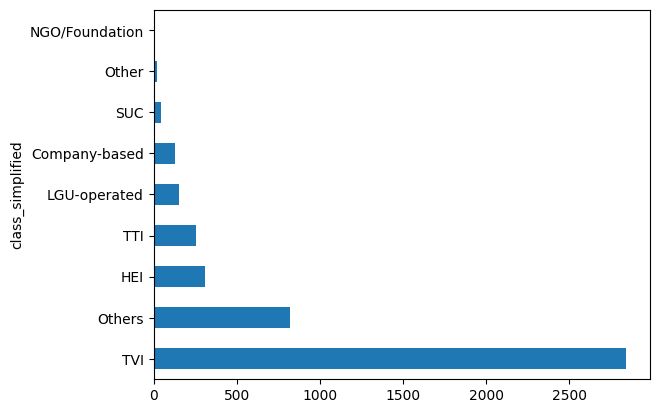

In [6]:
df_stats['class_simplified'].value_counts().plot(kind='barh')

questions to ask:
Total enrollment across all programs, total graduates, number of distinct qualifications, assessment pass rates where available

to do: fix the fact that you dont know which contacts are for which programs. like it is possible that a center may have multiple center managers for different programs

how many institutions by type, by region, enrollment distribution, largest and smallest providers, geographic concentration and gaps

 Create CRM views and filters for key segments: private TVIs by region, private
HEIs by enrollment size, institutions with no existing Wadhwani relationship,
institutions in priority regions

In [7]:
conn = sqlite3.connect("egac.db")

query = """
SELECT
    qualification_name,
    SUM(num_enrolled) AS total_enrolled,
    SUM(num_graduated) AS total_graduates,
    SUM(num_assessed) AS total_assessed,
    SUM(num_certified) AS total_certified,
    CASE 
        WHEN SUM(num_assessed) > 0
        THEN SUM(num_certified) * 1.0 / SUM(num_assessed)
        ELSE NULL
    END AS pass_rate
FROM program
GROUP BY qualification_name
ORDER BY total_enrolled DESC;
"""

df_enrollments = pd.read_sql_query(query, conn)
conn.close()


In [8]:
df_enrollments[df_enrollments['pass_rate'] < 0.8].sort_values(by='total_assessed', ascending=False)

,qualification_name,total_enrolled,total_graduates,total_assessed,total_certified,pass_rate
14,Bookkeeping NC III,14654,12078,7038,3459,0.491475
83,Animation NC II,319,384,1131,806,0.712644
87,Housekeeping NC III,249,272,1090,794,0.728440
182,Food and Beverage Services NC IV,0,0,403,262,0.650124
134,Web Development NC III,23,72,283,144,0.508834
98,Medical Transcription NC II,139,127,194,130,0.670103
141,Mechanical Drafting NC I,13,16,146,97,0.664384
133,Emergency Medical Services NC III,24,12,113,84,0.743363
129,Electrical Installation and Maintenance NC IV,31,27,98,74,0.755102
146,Transport RAC Servicing NC II,0,0,75,43,0.573333


In [9]:
df_stats.head()

,institution_id,institution_name,class,city,region,num_centers,num_qualifications,total_trainers,total_enrolled,total_graduates,total_accredited_assessors,total_assessed,total_certified,num_program,class_simplified
0,1928,(S.J.B.) SAINT JOHN BOSCO I.A.S. INC.,TVIs,Angono,Region IVA - CALABARZON,1,1,1,12,28,0,0,0,1,TVI
1,1927,(S.J.B.) SAINT JOHN BOSCO I.A.S. INC. - (MANDA...,TVIs,Mandaluyong City,National Capital Region (NCR),1,2,4,173,164,0,0,0,2,TVI
2,2615,(S.J.B.) SAINT JOHN BOSCO I.A.S. INC. - (PASIG...,TVIs,Pasig City,National Capital Region (NCR),1,2,2,118,110,0,0,0,2,TVI
3,2194,"1 AND ALL TECHNICAL SCHOOL, INC.",TVIs,City of El Salvador,Region X - Northern Mindanao,1,2,5,226,226,0,0,0,2,TVI
4,3405,1ST INTERNATIONAL COMPUTER TECHNOLOGY COLLEGES...,TVIs,City of Tarlac,Region III - Central Luzon,1,1,1,12,12,0,0,0,1,TVI


<Axes: ylabel='institution_name'>

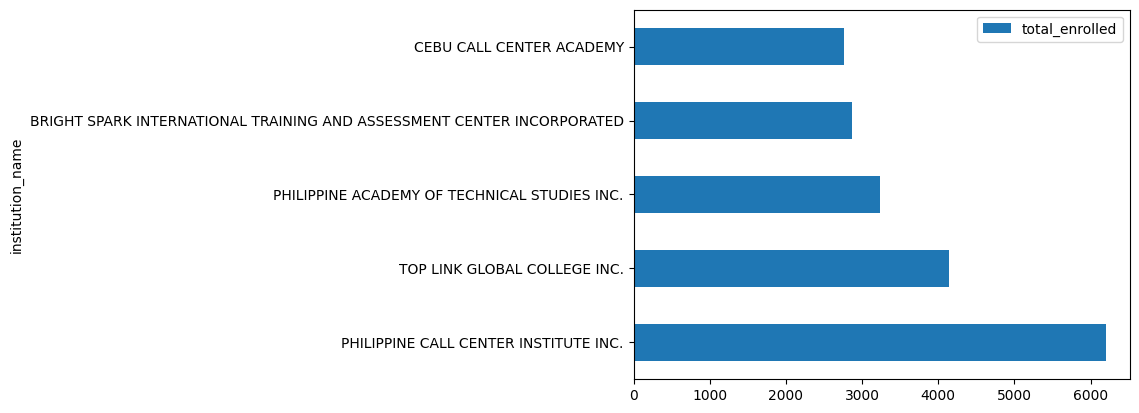

In [10]:
df_stats[df_stats['class_simplified'] == 'TVI'] \
.sort_values(by='total_enrolled', ascending=False) \
[['institution_name', 'total_enrolled']] \
.head(5) \
.plot(kind='barh', x='institution_name', y='total_enrolled')

In [11]:
df_stats[df_stats['class_simplified'] == 'HEI'].sort_values(by='total_graduates', ascending=False).head(5)

,institution_id,institution_name,class,city,region,num_centers,num_qualifications,total_trainers,total_enrolled,total_graduates,total_accredited_assessors,total_assessed,total_certified,num_program,class_simplified
2788,1239,"NORTH CENTRAL MINDANAO COLLEGE, INC.",HEIs,Lala,Region X - Northern Mindanao,2,13,25,1677,2094,10,682,627,22,HEI
3868,1893,SOUTHERN LUZON TECHNOLOGICAL COLLEGE FOUNDATIO...,HEIs,Legazpi City,Region V - Bicol,4,10,18,1042,1426,9,319,249,17,HEI
408,80,B.E.S.T. COLLEGE OF POLOMOLOK (B.E.S.T. POLOMO...,HEIs,Polomolok,Region XII - SOCCSKSARGEN,1,18,31,1455,1387,0,0,0,18,HEI
912,1019,COLEGIO DE SANTO CRISTO DE BURGOS CORPORATION,HEIs,Sariaya,Region IVA - CALABARZON,2,9,11,1107,1187,9,213,204,14,HEI
1233,1782,EAST PACIFIC COMPUTER COLLEGE INC.,HEIs,Catarman,Region VIII - Eastern Visayas,1,4,8,949,928,0,0,0,4,HEI


<Axes: ylabel='institution_name'>

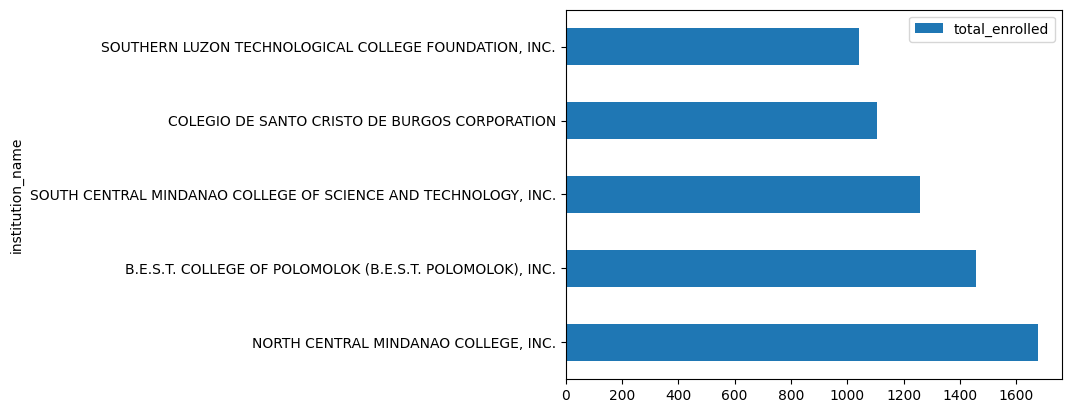

In [12]:
df_stats[df_stats['class_simplified'] == 'HEI'] \
.sort_values(by='total_enrolled', ascending=False) \
[['institution_name', 'total_enrolled']] \
.head(5) \
.plot(kind='barh', x='institution_name', y='total_enrolled')

In [13]:
df_stats.groupby('region')[['total_enrolled', 'total_graduates', 'total_assessed', 'total_certified']].sum().sort_values(by='total_enrolled', ascending=False)

,total_enrolled,total_graduates,total_assessed,total_certified
region,,,,
National Capital Region (NCR),107169,102013,34681,33785
Region III - Central Luzon,80635,69011,33304,30300
Region IVA - CALABARZON,74815,66376,25917,25259
Region X - Northern Mindanao,48595,50255,16495,15360
Region I - Ilocos,45265,39447,20118,18910
Region VII - Central Visayas,44456,43802,20237,19426
Region VIII - Eastern Visayas,44421,37794,16901,17033
Region V - Bicol,30685,29214,17702,16096
Region IVB - MIMAROPA,30473,27957,13711,13315
